![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Agnostic Interpretation with SHAP

In this Notebook, we will demonstrate how to use the SHapley Additive exPlanations (SHAP) method and interpret its results.

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-transformer/2-Tutorial_AttentionMaps_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
A folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also receive an email that informs you about the access on your Google Drive.

In [1]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [2]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [3]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-transformer.txt
# %cd xai-for-transformer

### Imports

In [4]:
import os
import torch
import transformers

import zipfile
import requests
import datasets
import pandas as pd

import shap

import sys  
sys.path.append('./')
import utils

# Select the best available device: NVIDIA GPU (CUDA), Apple Silicon GPU (MPS), or CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


---

## Data and Model Loading: The Emotions Dataset

In this notebook, we will work with the **Emotion dataset**, containing English text samples labelled with one of six emotions: **sadness, joy, love, anger, fear,** or **surprise**. Each row consists of a short text and its corresponding emotion label. We will use the predefined dataset split, which contains 16,000 training samples, 2,000 validation samples, and 2,000 test samples. Our goal is to **predict the emotion expressed in a text** and use SHAP to investigate which words and tokens contribute most strongly to the model's predictions.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_emotions.png?raw=true" width="400" /></center>

In the notebook [*1-Tutorial_Transformer_Model.ipynb*](./1-Tutorial_Transformer_Model.ipynb), we introduced the Transformer architecture and the DistilBERT model used throughout this tutorial.

#### Load the Fine-Tuned Transformer Model

We begin by loading the **fine-tuned DistilBERT model** together with its corresponding tokenizer. The model has been fine-tuned on the Emotion dataset to classify text into one of the six emotion classes.

In [5]:
# Fine-tuned DistilBERT emotion weights, hosted as a GitHub Release asset (release v2.1.0).
url = "https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/releases/download/v2.1.0/distilbert_emotion_weights.zip"

data_dir = "../data"
zip_path = f"{data_dir}/distilbert_emotion_weights.zip"
weights_path = f"{data_dir}/distilbert-emotion"
os.makedirs(data_dir, exist_ok=True)

with open(zip_path, "wb") as f:
    f.write(requests.get(url).content)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

os.remove(zip_path)

In [6]:
# Load the fine-tuned DistilBERT model and its matching tokenizer. The tokenizer
# converts raw text into token IDs that the model can process, while the model
# predicts one of the six emotion classes from the tokenized input.
model = transformers.AutoModelForSequenceClassification.from_pretrained(weights_path).to(device)
tokenizer = transformers.AutoTokenizer.from_pretrained(weights_path)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## Now, what does my model think is important in the text?

### SHapley Additive exPlanations (SHAP)

**Before starting with the practical example, watch our [video introduction to SHAP](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap_theory.html#video-introduction) to understand the general idea behind Shapley-based feature attribution.**

Since we are working with **text data** in this notebook, also have a look at the [SHAP for Text Data](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap_text.html) section to understand what the features are, how missing tokens can be represented, and how the baseline is defined for text explanations.

*Note: All references can be found [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html#references).*

<font color='green'>

#### Question 1: What does a SHAP value tell you about the contribution of a text feature to an individual prediction?

<font color='grey'>

#### Your Answer:

* A SHAP value describes how much a text feature contributes to moving the model output from the baseline toward the prediction for the individual text.

* A positive SHAP value contributes toward increasing the model output for the class being explained, while a negative SHAP value contributes toward decreasing it. The magnitude indicates the strength of the contribution.


<font color='green'>

#### Question 2: What are the "features" or "players" when SHAP is applied to text data?

<font color='grey'>

#### Your Answer:

* For text models, the features are typically the **tokens** that make up the input sequence.

* Depending on the tokenizer, a token does not necessarily correspond to a complete word. A word can also be split into several subword tokens, which then receive separate feature attributions.


<font color='green'>

#### Question 3: What happens when a token is treated as missing from a coalition?

<font color='grey'>

#### Your Answer:

* A text model still requires a valid input sequence, so a token cannot simply be treated as if no model input were required at that position.

* A **text masker** defines how missing token information is represented, for example by replacing tokens with a mask token where supported. The chosen masking strategy influences the coalition values and therefore the resulting feature attributions.


<font color='green'>

#### Question 4: Why can the definition of feature coalitions be particularly important for text?

<font color='grey'>

#### Your Answer:

* Tokens are strongly **context-dependent**: the meaning and effect of one token often depends on the surrounding tokens. Arbitrary combinations of present and missing tokens can therefore create unnatural or difficult-to-interpret text inputs.

* Grouping related or neighboring tokens in a **hierarchical structure** can better respect the structure of the text. It also reduces the number of unrestricted token combinations that need to be considered in the attribution problem.

### SHAP Explainers

So far, we have learned what SHAP values represent. However, **SHAP is an attribution framework, not a single algorithm**. Different SHAP explainers use different computational strategies to obtain feature attributions. Some explainers are model-agnostic and treat the model as a black box, while others can exploit properties of particular model types.

For text data, **PartitionExplainer** is particularly interesting because tokens have a meaningful sequential and hierarchical structure. Related tokens can be grouped together, allowing the attribution game to consider groups of tokens before recursively distributing their contributions to individual tokens.

Other explainers could also be used for our DistilBERT classifier:

| Explainer | Applicable to our model? | Main consideration |
|---|---|---|
| **PartitionExplainer** | Yes | Model-agnostic and can exploit a hierarchy of related tokens. Particularly suitable for structured text inputs. |
| **PermutationExplainer** | Yes | Model-agnostic and can work with masked text inputs, but generally requires more model evaluations because it does not exploit the token hierarchy in the same way. |
| **KernelExplainer** | Yes | Model-agnostic, but becomes expensive as the number of tokens grows because many coalition evaluations are required. |
| **SamplingExplainer** | Yes | Model-agnostic Monte Carlo approximation of Shapley values, but does not specifically exploit the hierarchical structure of text. |
| **Gradient-based explainers** | In principle | DistilBERT is differentiable, but its direct inputs are discrete token IDs. Gradient-based attribution therefore needs to operate on token embeddings or another differentiable representation, making the setup and interpretation less straightforward than for continuous image inputs. |

In this notebook, we focus on **PartitionExplainer**. It provides a natural connection between the structure of text and the attribution game, works without access to the internal gradients of DistilBERT, and integrates directly with SHAP's text masker.

### PartitionExplainer for DistilBERT and Emotions Dataset

PartitionExplainer is a model-agnostic method that uses a hierarchical structure of features to constrain the attribution game. It only requires access to the inputs and predictions of our DistilBERT classifier and does not require access to its gradients or internal architecture.

For text, this hierarchy groups related tokens into increasingly larger parts of the input sequence. This is particularly useful because text can contain tens or hundreds of tokens, making it computationally infeasible to consider every possible subset. Instead, PartitionExplainer evaluates groups of tokens according to the hierarchy and recursively distributes their contributions down to individual tokens. Because the hierarchy changes which feature coalitions are considered, PartitionExplainer computes **Owen-value-based attributions** rather than unrestricted Shapley values.

For text data, PartitionExplainer works together with a text masker, which has two important roles:

1. It defines **how tokens are represented when they are missing** from a coalition.
2. It provides the **hierarchical partition of the text** used to group related tokens and recursively distribute contributions down to individual tokens.

PartitionExplainer creates different masked versions of the text according to this hierarchy and evaluates them with the original model. Changes in the model output are then used to determine how token groups, and eventually individual tokens, contribute to the prediction.

📖 **Want to understand how PartitionExplainer and Owen values work in detail?** See the [PartitionExplainer explanation](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap_explainers.html#partitionexplainer).

**Setting Up Our DistilBERT Classifier**

We first create a Hugging Face text-classification pipeline for our fine-tuned DistilBERT model. The pipeline provides a convenient inference interface that handles the required preprocessing, including tokenization and batching, before passing the inputs to the model.

We configure the pipeline to return prediction scores for all six emotion classes rather than only the most likely class. This is important because the explanation is class-specific: PartitionExplainer needs access to the model output for each emotion to determine how the tokens contribute to the different class predictions.

In [7]:
# Wrap the model and tokenizer into a high-level inference interface that handles
# tokenization, batching, and prediction. Setting top_k=None returns prediction
# scores for all emotion classes, which are required later for SHAP explanations.
classifier_pipeline = transformers.pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
    top_k=None,
)

# Store the mapping from predicted emotion names to their numerical class IDs so
# that model predictions can be compared to the ground-truth labels in the dataset.
label2id = model.config.label2id

**Evaluate the Model**

Before interpreting the model with SHAP, it is good practice to verify that it performs well on the prediction task. We therefore evaluate the fine-tuned DistilBERT model on both the training and test splits of the Emotion dataset. We report the **balanced accuracy** (the mean recall across the six classes), which gives a fairer picture on the rarer emotions than plain accuracy would, since the dataset is imbalanced.

In [8]:
# Load the training split of the Emotion dataset and store it as a pandas DataFrame
# for later analysis throughout the notebook.
dataset_train = datasets.load_dataset("dair-ai/emotion", split="train")
data_train = pd.DataFrame({"text": dataset_train["text"], "emotion": dataset_train["label"]})

# Evaluate the model on the training data using the helper function defined above.
print(f"TRAIN balanced accuracy: {utils.evaluate_model(classifier_pipeline, data_train, label2id):.4f}")

# Repeat the same procedure for the test split to assess how well the model
# generalizes to previously unseen data.
dataset_test = datasets.load_dataset("dair-ai/emotion", split="test")
data_test = pd.DataFrame({"text": dataset_test["text"], "emotion": dataset_test["label"]})
print(f"TEST balanced accuracy: {utils.evaluate_model(classifier_pipeline, data_test, label2id):.4f}")

TRAIN balanced accuracy: 0.9498
TEST balanced accuracy: 0.8776


As we can see by the numbers above, our model performs well on the training set and also generalizes well to the independent test set.

**You should keep in mind that interpreting a low-performing model can lead to wrong conclusions.**

**Defining the Text Masker**

A transformer cannot evaluate a coalition with tokens simply removed without defining what the resulting model input should look like. We therefore use `shap.maskers.Text` together with the tokenizer of our DistilBERT model.

When a token is treated as missing, the masker creates a valid masked version of the text that can still be processed by the tokenizer and model. The exact representation of missing tokens depends on the tokenizer and masker configuration.

The text masker also provides the hierarchical grouping of tokens used by PartitionExplainer. Instead of treating all arbitrary combinations of tokens as equally valid coalitions, related parts of the text can first be considered together and then recursively divided into smaller groups.

For example, a simplified hierarchy could look like:

```text
              "I really love this movie"
                    /          \
           "I really"      "love this movie"
             /   \            /         \
           "I" "really"    "love"    "this movie"
                                      /       \
                                   "this"    "movie"

In [9]:
masker = shap.maskers.Text(tokenizer)

**Creating the PartitionExplainer**

We now combine the classifier pipeline with the text masker. PartitionExplainer will use the masker to generate the required perturbed texts and the classifier pipeline to obtain the corresponding model outputs.

In [10]:
explainer = shap.PartitionExplainer(classifier_pipeline, masker)

To explore how our model uses the text features, we first compute attributions for a **subset of the training data**. These samples come from the distribution the model encountered during training and provide a useful starting point for investigating its learned prediction behavior.

We explain multiple texts rather than a single example so that the resulting attributions can be used at two levels: **locally**, to understand individual predictions, and **globally**, by aggregating attributions across samples to identify broader patterns in the model's behavior.

In [11]:
# Compute SHAP values for the first 100 training samples
# Silent argument suppresses progress bar output
shap_values_train = explainer(data_train["text"][:100], silent=True)

**Structure of the Text Explanations**

After computing the feature attributions, we can inspect the resulting `Explanation` object. Its structure differs from the tabular case because text inputs consist of **variable-length sequences of tokens** rather than the same fixed set of named features for every sample.

For **tabular data**, every sample is described by the same features. For example, every house in the California Housing dataset is represented by the same eight variables:

| Sample | Features |
|--------|----------|
| House 1 | MedInc, HouseAge, AveRooms, ... |
| House 2 | MedInc, HouseAge, AveRooms, ... |
| House 3 | MedInc, HouseAge, AveRooms, ... |

This gives us a fixed feature space. SHAP values can therefore naturally be organized as **samples × features** (with an additional output dimension when multiple model outputs are explained).

For **text data**, each sample is instead represented by the sequence of tokens produced by the tokenizer:

| Sample | Tokens |
|--------|--------|
| Text 1 | *I*, *feel*, *happy* |
| Text 2 | *I*, *feel*, *extremely*, *happy*, *today* |
| Text 3 | *Happy*, *!* |

Different texts can contain different numbers of tokens, and the token at a particular position does not represent the same feature across samples. For example, the third token might be `happy` in one text and `extremely` in another.

There is therefore no single fixed **samples × named features** matrix analogous to the tabular case. Instead, each text has its own sequence of token-level attributions. For every token in a text, PartitionExplainer provides a separate attribution for each model output being explained.

We can now inspect the `Explanation` object produced by SHAP for the first 100 training texts.

In [12]:
# Number of input sentences
print(f"Number of input sentences: {len(shap_values_train.values)}")

# Number of emotion classes
print(f"Number of classes: {shap_values_train.values[0].shape[1]}")

# Number of tokens in the first five texts
for i in range(5):
    print(f"Text {i}: {len(shap_values_train.data[i])} tokens")

Number of input sentences: 100
Number of classes: 6
Text 0: 7 tokens
Text 1: 23 tokens
Text 2: 12 tokens
Text 3: 22 tokens
Text 4: 8 tokens


As expected, the explanation contains one entry for each of the 100 texts and provides SHAP values for all six emotion classes. However, the number of tokens differs from one text to another, meaning that each explanation has its own token dimension rather than sharing a common set of features.

*Note: Since DistilBERT uses WordPiece tokenization, some words may be split into multiple tokens. SHAP therefore explains the contribution of individual tokens rather than complete words.*

### Local Explanations with SHAP

Local explanations help us understand **why the model made a specific prediction for an individual text**. Instead of summarizing the model's behavior across the entire dataset, they attribute the prediction to the words or tokens present in a single input.

For each explained text, SHAP assigns a contribution to every token. Positive SHAP values indicate that a token increases the model's confidence in the selected emotion, while negative SHAP values indicate that it decreases the confidence. The magnitude of the SHAP value reflects how strongly the token influences the prediction.

In the following examples, we use the previously computed SHAP values to inspect individual predictions and identify the words that are most responsible for the model's decisions.

#### Force Plot

*What is a Force Plot?*

The force plot explains how individual tokens contribute to the model's prediction for **a single text and a selected output class**. Since our classifier has multiple outputs, there is a separate baseline for each emotion class, corresponding to the model's baseline output for that class. For a selected emotion, the baseline represents the model output when no information from the explainable input tokens is available, i.e., for the empty coalition defined by our text masker. The token attributions then explain how the model output moves from this baseline to the prediction for the complete text. Because the attributions are additive, the contributions of all tokens sum to the difference between the baseline and the model output for the selected class:

*How to Interpret the Visualization*

For our six-class emotion classifier, the force plot contains a separate explanation for each emotion class. At the top of the figure, all six outputs are listed. Selecting an emotion shows how the tokens contribute specifically to that class output.

The horizontal force visualization shows how the token contributions move the model output from the class-specific baseline to the final output for the text. Red contributions increase the model output for the selected class, whereas blue contributions decrease it. Larger contributions exert a stronger "force" on the model output.

The input text is shown below the force visualization, with each token colored according to its contribution for the selected class. Red tokens support a higher output for that emotion, while blue tokens push the output lower. The color intensity indicates the strength of the contribution, making it easy to identify which parts of the text have the strongest influence on the selected class output.

In [13]:
# Visualize the token-level SHAP values for the eighth training sentence,
# showing how each word contributes to the prediction of each emotion class.
shap.plots.text(shap_values_train[6])

In [14]:
# Visualize the token-level SHAP values for the eighth training sentence,
# showing how each word contributes to the prediction of each emotion class.
shap.plots.text(shap_values_train[7])

While the previous visualization shows the contributions of each token to all emotion classes, we can also focus on a single emotion. By selecting one output class, the force plot displays only how each token influences the model's prediction for that specific emotion. This is particularly useful when comparing explanations across different emotion classes or when investigating why the model assigned a high or low score to one class.

In [15]:
# Visualize how each token contributes to the prediction of the "fear" class
# for the eighth training sentence.
shap.plots.text(shap_values_train[7, :, "fear"])

In [16]:
# Visualize how each token contributes to the prediction of the "anger" class
# for the eighth training sentence.
shap.plots.text(shap_values_train[7, :, "anger"])

When comparing force plots across different emotion classes, remember that each class has its own baseline. SHAP values explain how the model moves from that class-specific baseline to the final prediction. As a result, the size of token contributions should always be interpreted relative to the corresponding baseline and final model output, rather than being compared directly across different classes.

### Global Explanations with SHAP

The local explanation plots help us understand why the model made a specific prediction for an individual text by highlighting the contribution of each token. However, we are often interested in understanding the model's behavior **across many predictions**. For example, which words are generally the most influential for the model? Are there tokens that consistently contribute to certain emotions?

SHAP addresses these questions by aggregating the local explanations of multiple samples into global explanations. By analyzing SHAP values across the dataset, we can identify the tokens that have the greatest overall impact on the model's predictions and gain a broader understanding of the patterns the transformer has learned.

#### Bar Plot

The bar plot provides a global summary of how tokens contribute to the selected emotion class across multiple texts. Instead of visualizing the attributions for a single prediction, it **groups occurrences of the same token across all explained texts** and aggregates their attribution values. Here, we use `.mean(0)`. For text explanations, SHAP first collects the attribution values belonging to the same token and then computes their mean signed attribution. Importantly, the mean is calculated over the **occurrences of that token**, not over all explained texts. For example, if the token *afraid* occurs in 10 of the explained texts, its mean is calculated from those 10 attribution values; texts in which *afraid* does not occur do not contribute a zero value.

The sign of the resulting value is preserved. A positive mean indicates that the token tends, on average when it occurs, to increase the model output for the selected emotion relative to the baseline, whereas a negative mean indicates that it tends to decrease the model output. If a token has positive contributions in some contexts and negative contributions in others, these effects can partially cancel. The resulting bar plot therefore answers a question such as: **When this token occurs in the explained texts, how does it tend to affect the model output for this emotion?**

Since the aggregation is based on the explained samples, the resulting summary also depends on which texts are included. Using a larger and representative set of texts increases the number and diversity of token occurrences and therefore provides a broader picture of the model's behavior on that data distribution.

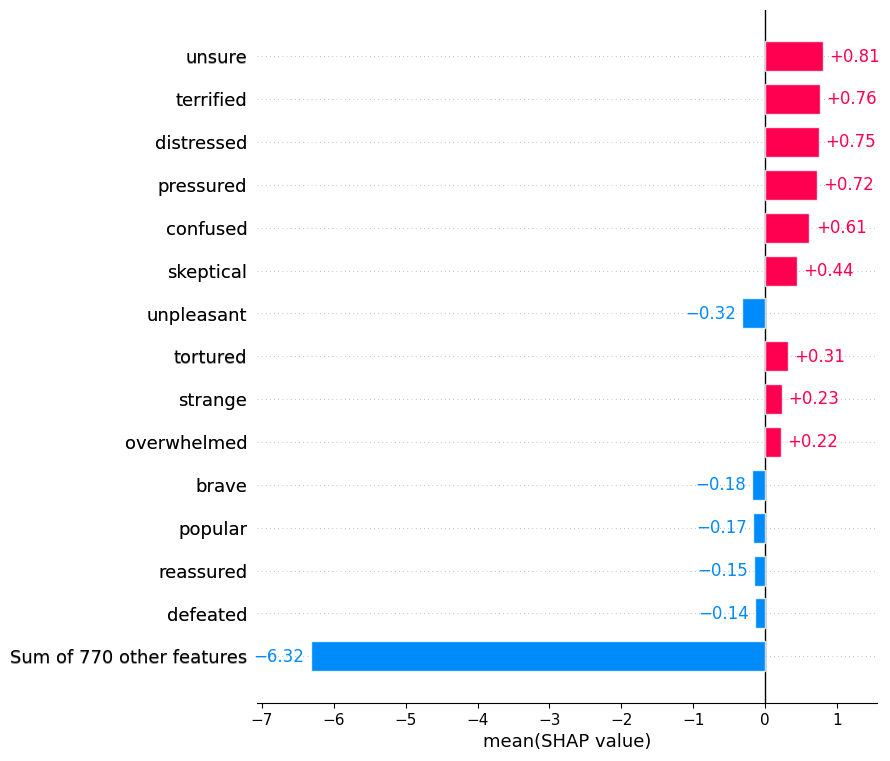

In [17]:
# Aggregate the token-level SHAP explanations for the "fear" class across
# all explained texts and visualize the resulting global token importance.
shap.plots.bar(shap_values_train[:, :, "fear"].mean(0), max_display=15)

The bar plot above preserves the direction of the token contributions, allowing us to see whether a token tends to increase or decrease the model output for fear. Alternatively, we could take the absolute value of the token attributions before aggregating them. This would answer a slightly different question: *Which tokens tend to have the strongest influence on the fear output, regardless of whether they increase or decrease it?*

```Python
shap.plots.bar(shap_values_train[:, :, "fear"].abs.mean(0))
```

Additionally, because the signed mean preserves the direction of the contributions, we can sort the aggregated attributions in descending or ascending order to separately inspect the tokens with the strongest average positive and negative effects.

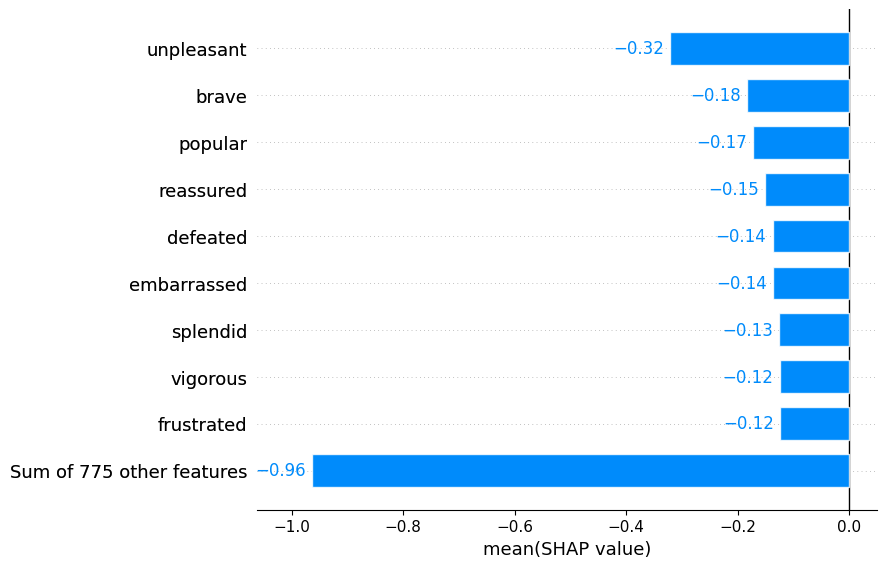

In [18]:
# we can sort the bar chart in decending order
shap.plots.bar(shap_values_train[:, :, "fear"].mean(0), order=shap.Explanation.argsort, max_display=10)

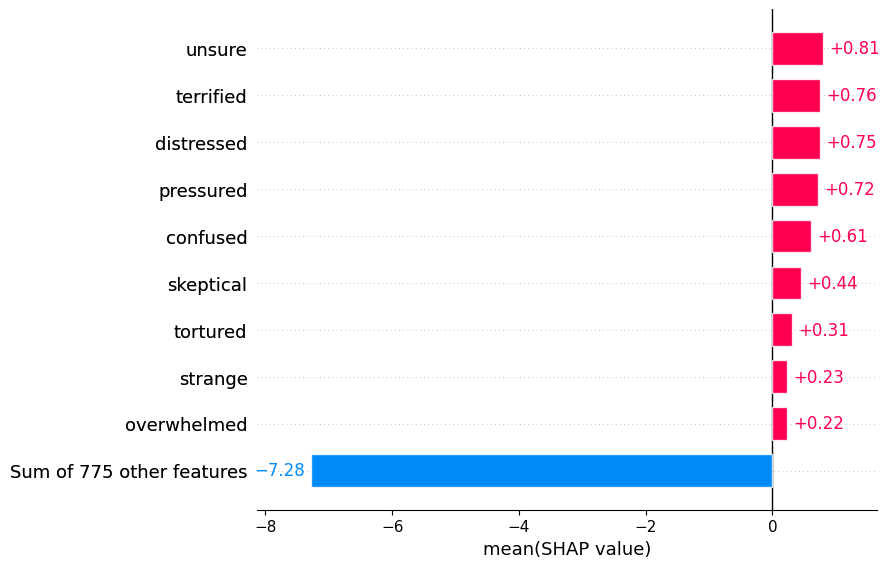

In [19]:
# ...or ascending order
shap.plots.bar(shap_values_train[:, :, "fear"].mean(0), order=shap.Explanation.argsort.flip, max_display=10)

Overall, the global bar plots reveal that the model relies primarily on semantically meaningful emotion-related words. Tokens such as terrified, distressed, confused, and unsure receive the largest positive SHAP values for the fear class, which is consistent with human intuition and suggests that the model has learned meaningful linguistic patterns. Many other tokens—including common words, punctuation, and subword fragments produced by the tokenizer—have only a small average influence and are therefore aggregated into the "Sum of other features" bar. This aggregation highlights that only a relatively small number of highly informative tokens dominate the global explanation, while the remaining tokens contribute comparatively little.

*Note: For transformer-based text models, SHAP primarily supports text (force) plots for local explanations and bar plots for global explanations. Visualizations such as beeswarm and dependence plots are designed for tabular data, where all samples share the same set of features. Since text samples contain variable-length token sequences rather than a fixed feature set, these visualizations are generally not applicable to transformer-based text models.*

<font color='green'>

#### Question 5: A token receives a high attention weight in the transformer but only a small attribution in the SHAP explanation. Is this a contradiction? What do the two quantities tell us?

<font color='grey'>

#### Your Answer:

* No. *Attention weights and feature attributions describe different aspects of the model.

* Attention weights describe how information is exchanged between tokens inside the transformer. A high attention weight therefore does not necessarily mean that the corresponding token has a large influence on the final prediction.

* The feature attribution instead describes how much the token contributes to moving the model output from the baseline toward the prediction for the selected class.

* Attention can therefore provide insight into the model's internal information flow, while SHAP-based attributions are directly related to the model output being explained.


<font color='green'>

#### Question 6: The force plot and the bar plot visualize the same token attributions. What different aspects of the explanation do they emphasize?

<font color='grey'>

#### Your Answer:

* The force plot emphasizes how the token contributions combine to move the model output from the baseline toward the prediction for the selected class. At the same time, the tokens remain visible in their original sentence context, making it easy to see which parts of the text push the prediction higher or lower.

* The bar plot focuses more directly on the magnitude and ranking of the token attributions, making it easier to identify and compare the tokens with the strongest positive or negative contributions.

* Both plots visualize the same underlying Owen-value-based attributions. They simply emphasize different aspects of the explanation: the force plot highlights the additive prediction process and linguistic context, while the bar plot makes the relative importance of individual tokens easier to compare.

<font color='green'>

#### Task: Apply SHAP to the Test Set

In this exercise, you will apply **SHAP** to the **test set** of the trained DistilBERT emotion classifier. Your goal is to investigate whether the explanations obtained on unseen data are consistent with those observed for the training set.

Your task is to:

1. Compute the SHAP values for the test set using the previously created `PartitionExplainer`.
2. Generate global SHAP bar plots for each emotion class.
3. Compare the globally important tokens with those identified on the training set.
5. Analyze whether the model relies on similar tokens and linguistic patterns when making predictions on unseen texts.
6. Based on your findings, discuss whether the SHAP explanations indicate that the model generalizes well to the test data.

</font>

In [20]:
shap_values_test = explainer(data_test["text"][:100], silent=True)

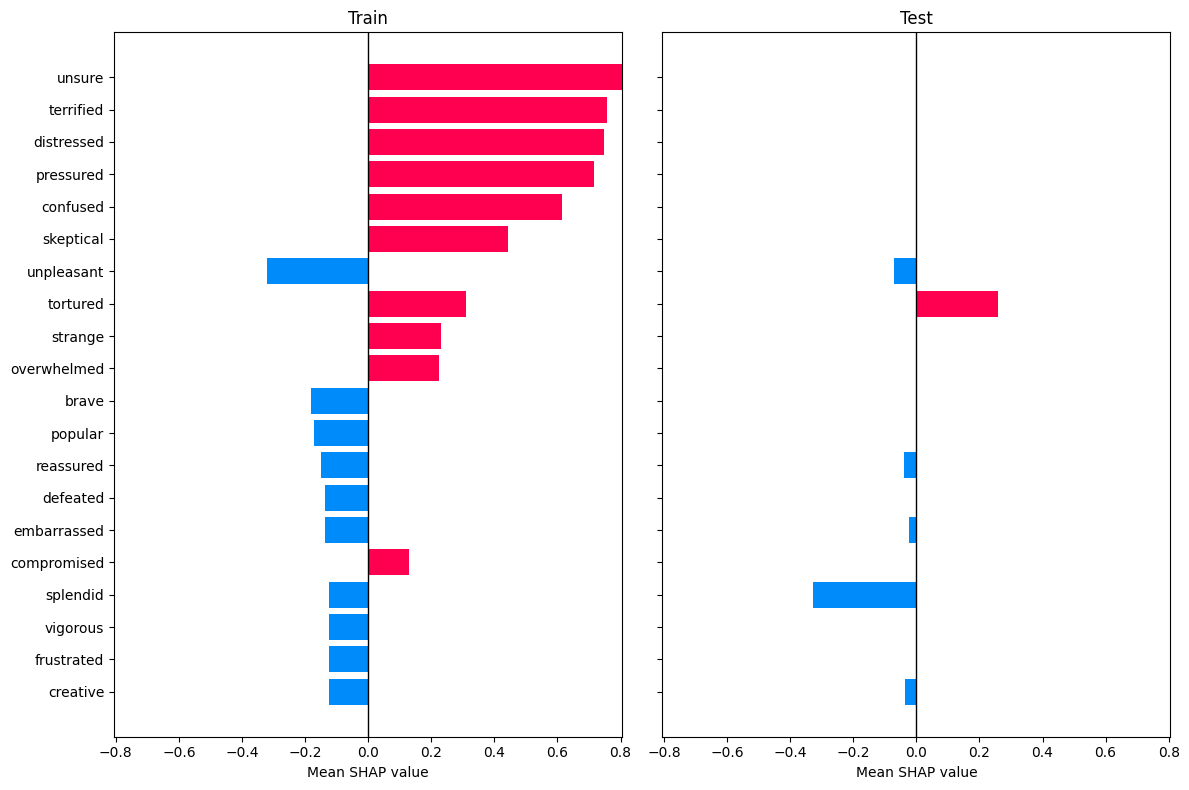

In [21]:
utils.plot_shap_values(shap_values_train, shap_values_test, output_name="fear", max_display=20)

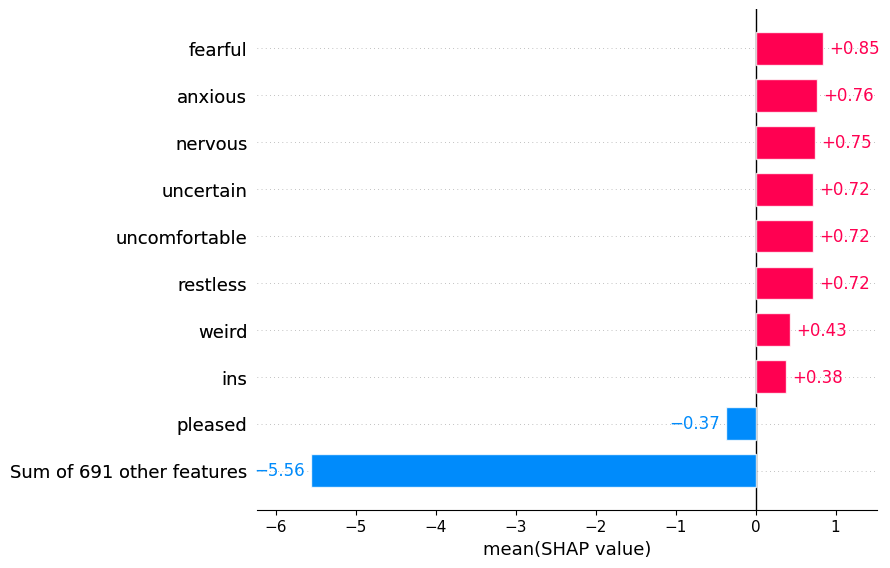

In [22]:
shap.plots.bar(shap_values_test[:, :, "fear"].mean(0), max_display=10)

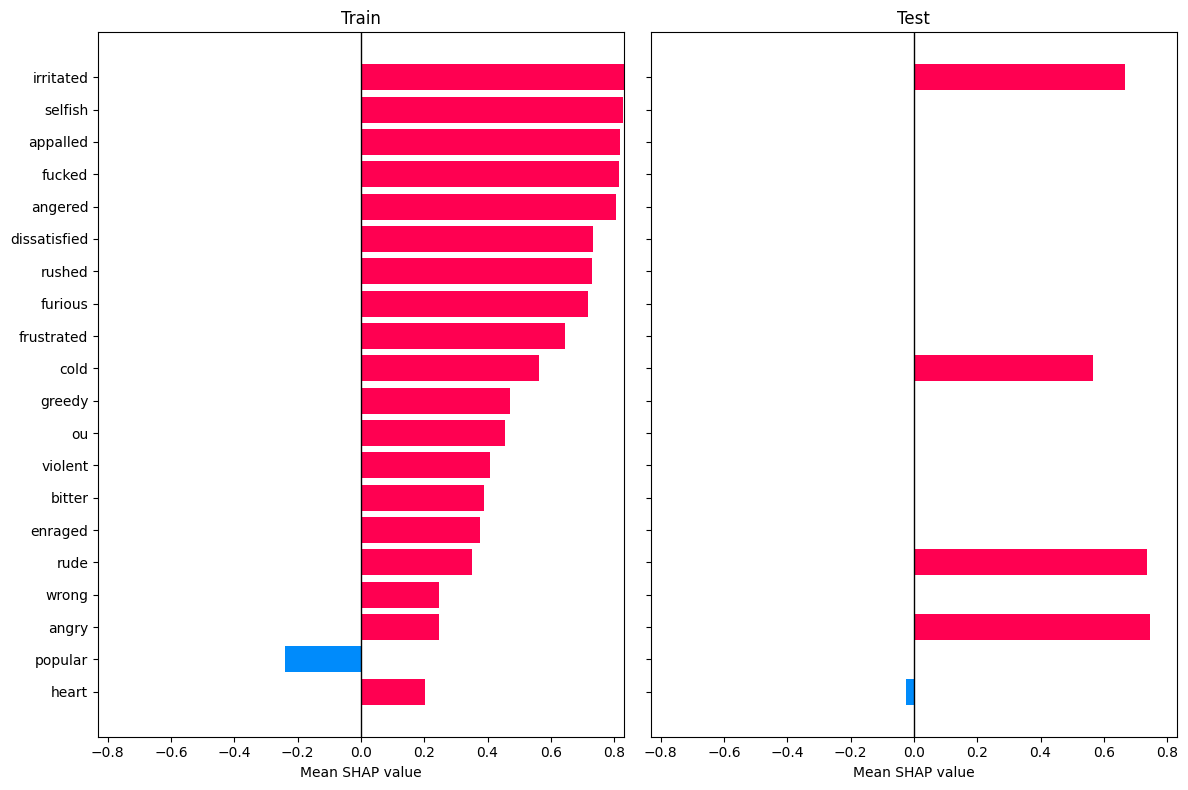

In [23]:
utils.plot_shap_values(shap_values_train, shap_values_test, output_name="anger", max_display=20)

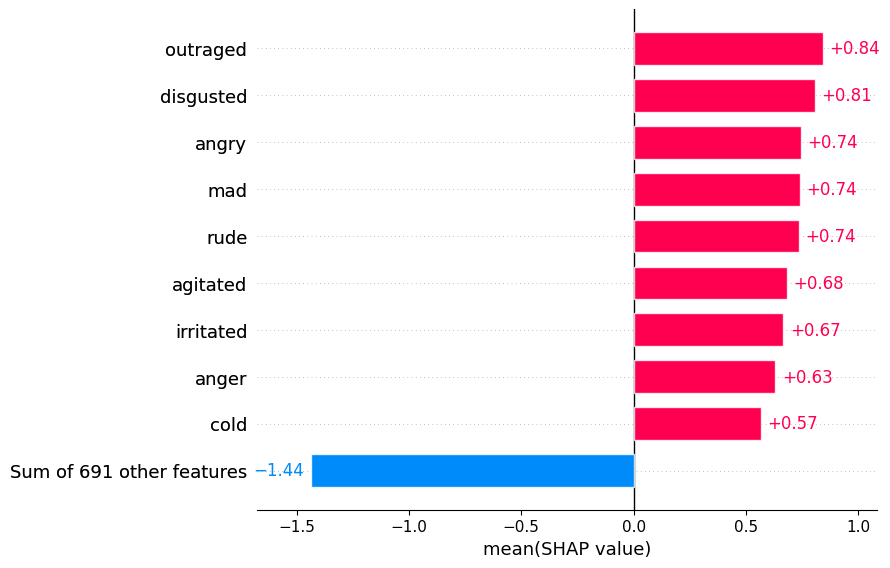

In [24]:
shap.plots.bar(shap_values_test[:, :, "anger"].mean(0), max_display=10)

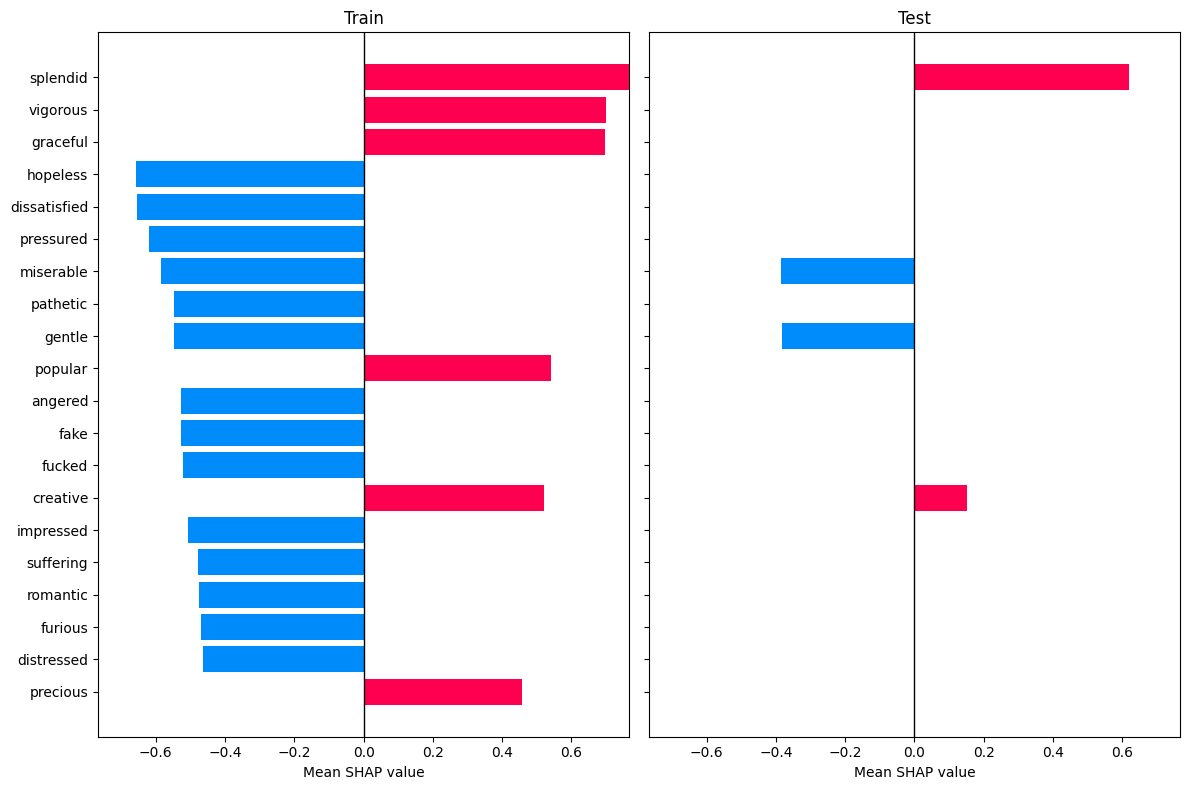

In [25]:
utils.plot_shap_values(shap_values_train, shap_values_test, output_name="joy", max_display=20)

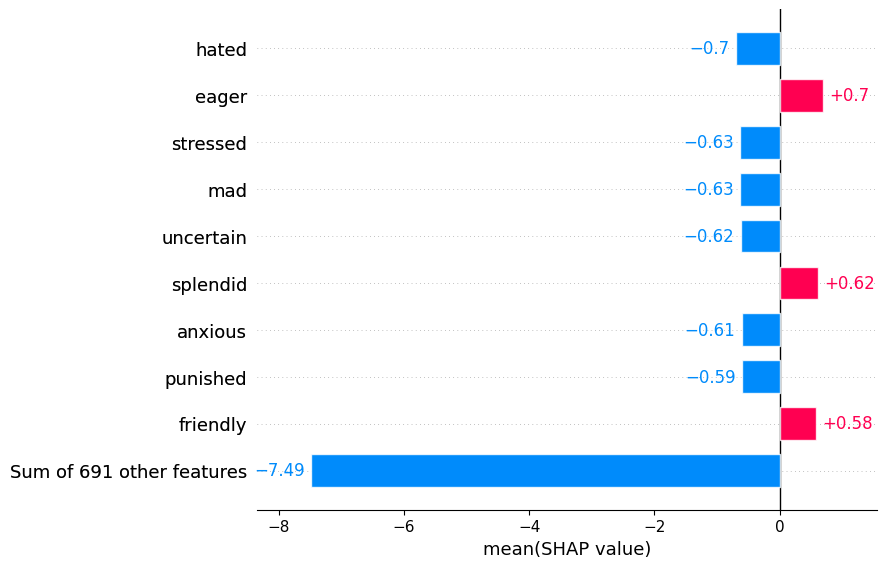

In [26]:
shap.plots.bar(shap_values_test[:, :, "joy"].mean(0), max_display=10)

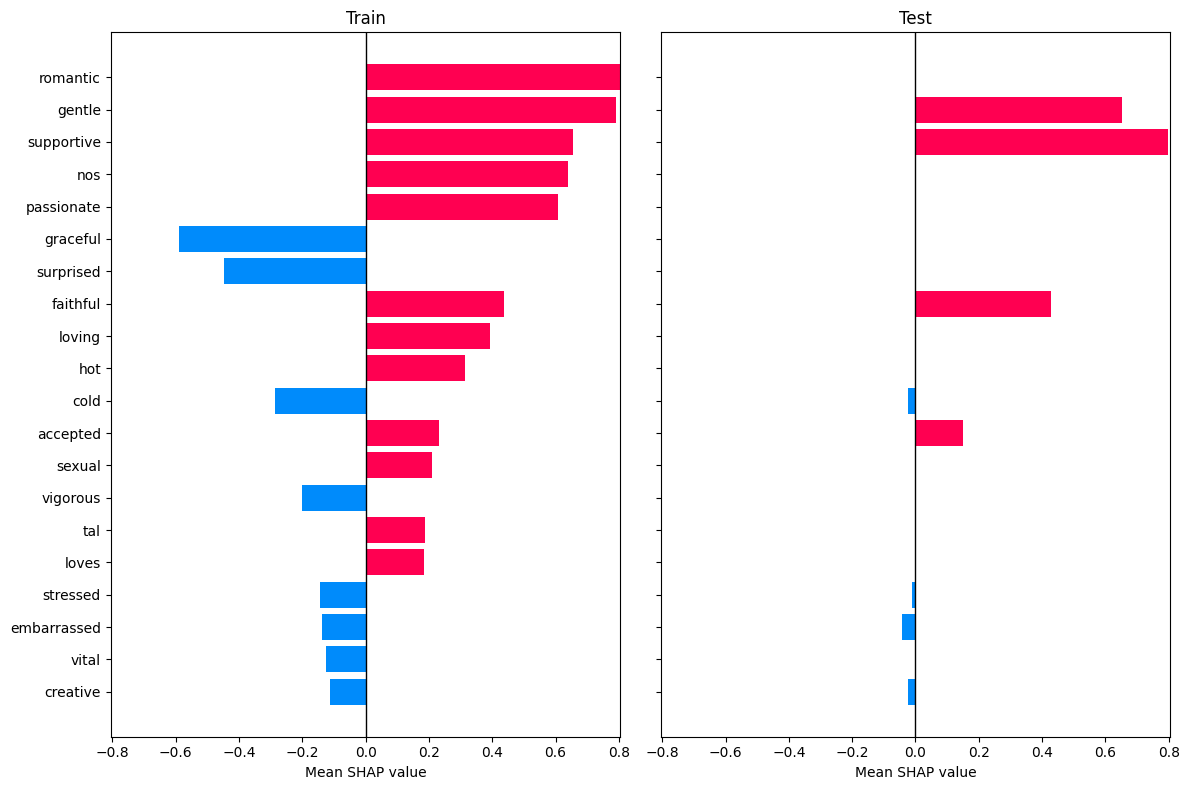

In [27]:
utils.plot_shap_values(shap_values_train, shap_values_test, output_name="love", max_display=20)

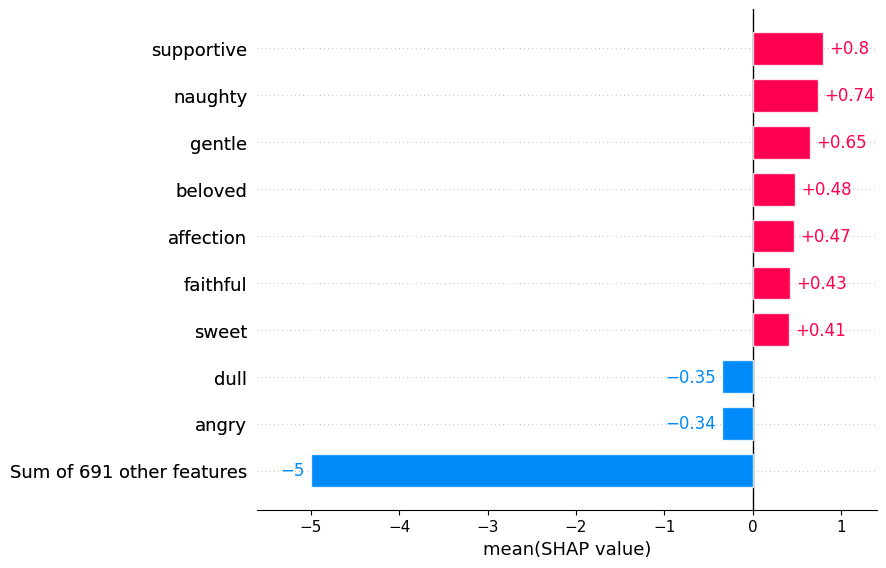

In [28]:
shap.plots.bar(shap_values_test[:, :, "love"].mean(0), max_display=10)

**Comparison of Train and Test SHAP Explanations**

The train and test explanations reveal that the exact tokens with the highest global SHAP values are not always the same. This is expected because global SHAP values summarize feature importance over a particular dataset, and the distribution of words naturally differs between the training and test sets. Rather than focusing on the overlap of individual tokens, it is more informative to consider whether the explanations remain semantically meaningful. The global SHAP bar plots for the test set continue to highlight words that are strongly associated with the corresponding emotions, indicating that the model relies on meaningful linguistic patterns when making predictions on unseen data. Overall, the differences in the most influential tokens reflect differences in the underlying texts rather than evidence of overfitting.

This behavior differs from SHAP explanations for tabular data. In tabular datasets, the same fixed set of features is available for every sample in both the training and test sets. Consequently, if a model generalizes well, we would generally expect the ranking of globally important features to be similar across the two datasets. In contrast, text data does not have a fixed feature set: each dataset contains different words and token frequencies, so the globally most important tokens may change even when the model has learned stable and meaningful decision patterns. Therefore, for text models it is often more appropriate to compare the semantic consistency of the explanations rather than expecting identical rankings of individual tokens.